# Solving ODEs using Block-Encoding Methods

In this notebook, we study an operator-encoding approach to differential equations. For the linear pendulum, the forward-Euler discretization gives a fixed linear update operator,

$$
u_{n+1}=Mu_n.
$$

The goal is to encode the generally non-unitary matrix $M$ into a larger unitary using block encoding.

Let

$$
B=\frac{M}{\alpha},
\qquad \alpha\geq \|M\|_2.
$$

A standard unitary dilation is

$$
U_B=
\begin{pmatrix}
B & \sqrt{I-BB^\dagger}\\
\sqrt{I-B^\dagger B} & -B^\dagger
\end{pmatrix}.
$$

Then the top-left block of $U_B$ is $M/\alpha$.

This works easily for small matrices. But, for a general $N\times N$ matrix, it is very hard to construct $2N \times 2N$ unitary matrix. That is why we later need more sophisticated methods such as 

1. LCU
2. FABLE
3. S-FABLE
4. LS-FABLE
5. other structure block-encoding methods

In this notebook, we focus only on the manual unitary-dilation construction as a baseline example. The naive-oracle and FABLE constructions are treated separately in later notebooks.

## Linear Pendulum 

The linear pendulum equation is

$$
\ddot{x}+\omega^2x=0.
$$

Introducing $y=\dot{x}$, this becomes the first-order system

$$
\dot{x}=y,\qquad \dot{y}=-\omega^2x.
$$

Let

$$
u_n=
\begin{pmatrix}
x_n\\
y_n
\end{pmatrix}.
$$

Using forward Euler with step size $h$,

$$
x_{n+1}=x_n+h y_n,
$$

$$
y_{n+1}=y_n-h\omega^2x_n.
$$

Therefore,
$
u_{n+1}=Mu_n,
$
where
$$
M= \begin{pmatrix}
1 & h\\
-h\omega^2 & 1
\end{pmatrix}
$$

The matrix $M$ is generally non-unitary, so it cannot be directly applied as a quantum gate. The Block-encoding method provides a way to embed this non-unitary update into a larger unitary circuit using ancillas and post-selection.

# Manual Block encoding method

In this section, we consider the manual block encoding construction of $U_M$ matrix given $M$ matrix.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

from qiskit import QuantumCircuit, transpile, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator


## Classical solution of Linear Pendulum 

In [2]:
def pendulum_update_matrix(h, omega):
    mat = np.array([[1.0, h],[-h * omega**2, 1.0]], dtype=complex)
    return mat

In [3]:
#Classical forward-Euler trajectory for the linear pendulum
def classical_euler_linear_pendulum(h, omega, x0, y0, n_steps):
    x_vals = [x0]
    y_vals = [y0]

    x, y = x0, y0

    for _ in range(n_steps):
        x_next = x + h * y
        y_next = y - h * omega**2 * x

        x, y = x_next, y_next

        x_vals.append(x)
        y_vals.append(y)

    t_vals = np.arange(n_steps + 1) * h
    return t_vals, np.array(x_vals), np.array(y_vals)

## Manual construction of Block encoding matrix

This creates the block encoding of a non-unitary matrix, $M$

In [4]:
#Function to create U matrix from M matrix
def manual_block_encoding(A, alpha=None, alpha_padding=1.001):
    #Non-unitary matrix
    A = np.array(A, dtype=complex)

    #Checking if matrix is not square
    if A.shape[0] != A.shape[1]:
        raise ValueError("A must be square.")

    #size of matrix -> N value
    n = A.shape[0]
    #2-Norm of A matrix
    norm_A = np.linalg.norm(A, 2)

    #Alpha = normalization factor
    #alpha padding = Small padding above the spectral norm for numerical stability.
    if alpha is None:
        alpha = alpha_padding * norm_A

    if alpha < norm_A - 1e-12:
        raise ValueError("alpha must satisfy alpha >= ||A||_2.")

    #Defining matrix B which is used to define block encoding matrix
    B = A / alpha
    I = np.eye(n, dtype=complex)

    #Defining each part of the block encoding matrix
    upper_right = sqrtm(I - B @ B.conj().T)
    lower_left = sqrtm(I - B.conj().T @ B)

    upper_right = np.real_if_close(upper_right, tol=1000)
    lower_left = np.real_if_close(lower_left, tol=1000)

    U = np.block([
        [B, upper_right],
        [lower_left, -B.conj().T]
    ])

    U = np.array(U, dtype=complex)

    return U, alpha

### Verifying the construction of the block matrix

In [5]:
h_test = 0.001
omega_test = 1

M = pendulum_update_matrix(h_test, omega_test)
U, alpha = manual_block_encoding(M)

n = M.shape[0]

top_left_block = U[:n, :n]

print("alpha =", alpha)
print("\nM / alpha:")
print(M / alpha)

print("\nTop-left block of U:")
print(top_left_block)

print("\nBlock-encoding error:")
print(np.linalg.norm(top_left_block - M / alpha))

print("\nUnitarity error:")
print(np.linalg.norm(U.conj().T @ U - np.eye(2 * n)))

alpha = 1.0010005004998748

M / alpha:
[[ 9.990005e-01+0.j  9.990005e-04+0.j]
 [-9.990005e-04+0.j  9.990005e-01+0.j]]

Top-left block of U:
[[ 9.990005e-01+0.j  9.990005e-04+0.j]
 [-9.990005e-04+0.j  9.990005e-01+0.j]]

Block-encoding error:
0.0

Unitarity error:
9.551406747998536e-19


The block-encoding error verifies that the top-left block of the constructed unitary is exactly $M/\alpha$. The unitarity error verifies that the full $4\times4$ matrix is unitary up to numerical precision. These two checks should be performed before using the block encoding in a time-stepping loop.

# Manual Block encoding (no circuits) (Classical way)

This implementation applies the block-encoding matrix directly using NumPy. This is a classical statevector-level validation of the block-encoding idea.

$$ u_{n+1} = M u_n
$$

In [6]:
#One Euler step using manual block encoding and direct statevector extraction
def manual_block_step_statevector_matrix(x, y, h, omega, alpha=None):
    #The present time vector u_n
    u = np.array([x, y], dtype=complex)
    norm_u = np.linalg.norm(u)

    if norm_u == 0:
        return 0.0, 0.0

    #Converting vector to quantum state (basically normalising)
    psi = u / norm_u

    #Block encoding of update matrix, M
    M = pendulum_update_matrix(h, omega)
    U, alpha = manual_block_encoding(M, alpha=alpha)

    # Block ordering:
    # |0>_anc |0>_sys
    # |0>_anc |1>_sys
    # |1>_anc |0>_sys
    # |1>_anc |1>_sys
    #Creating a vector that which block encoding matrix, U_M acts on
    input_state = np.concatenate([psi, np.zeros_like(psi)])

    #Obtaining output just by usual matrix multiplication
    output_state = U @ input_state

    # Ancilla |0> success branch.
    success_branch = output_state[:2]

    # Recover unnormalized classical update.
    u_next = alpha * norm_u * success_branch

    return np.real_if_close(u_next[0]).real, np.real_if_close(u_next[1]).real

### Full Trajectory Plots

In [7]:
def manual_block_trajectory_statevector_matrix(h, omega, x0, y0, n_steps, alpha=None):
    x_vals = [x0]
    y_vals = [y0]

    x, y = x0, y0

    for _ in range(n_steps):
        x, y = manual_block_step_statevector_matrix(
            x, y, h, omega, alpha=alpha
        )

        x_vals.append(x)
        y_vals.append(y)

    t_vals = np.arange(n_steps + 1) * h
    return t_vals, np.array(x_vals), np.array(y_vals)

In [9]:
h_1 = 0.001
omega_1 = np.sqrt(9.8)
x0 = np.pi/2
y0 = 1.0
n_steps = 10000

t_cl, x_cl, y_cl = classical_euler_linear_pendulum(
    h_1, omega_1, x0, y0, n_steps)

t_be, x_be, y_be = manual_block_trajectory_statevector_matrix(
    h_1, omega_1, x0, y0, n_steps)


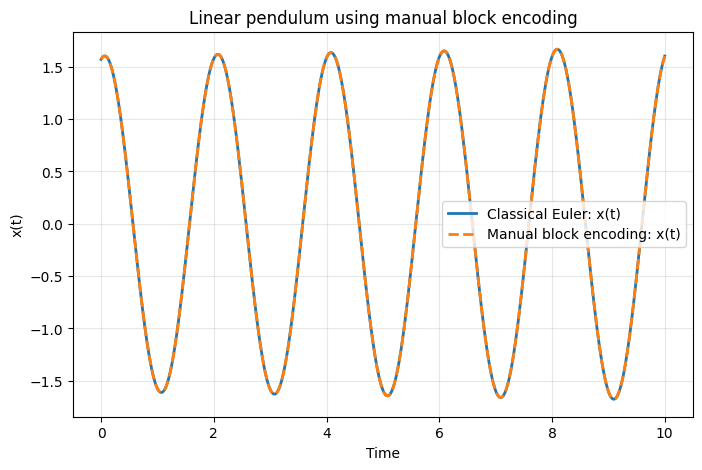

In [10]:
#Trajectory Plots
plt.figure(figsize=(8, 5))
plt.plot(t_cl, x_cl, label="Classical Euler: x(t)", linewidth=2)
plt.plot(t_be, x_be, "--", label="Manual block encoding: x(t)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Linear pendulum using manual block encoding")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


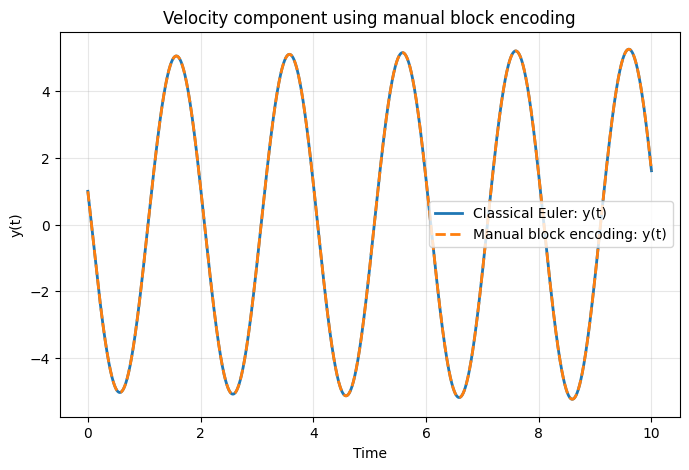

In [11]:
#Trajectory plot (Vecocity plot, y(t))
plt.figure(figsize=(8, 5))
plt.plot(t_cl, y_cl, label="Classical Euler: y(t)", linewidth=2)
plt.plot(t_be, y_be, "--", label="Manual block encoding: y(t)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("Velocity component using manual block encoding")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



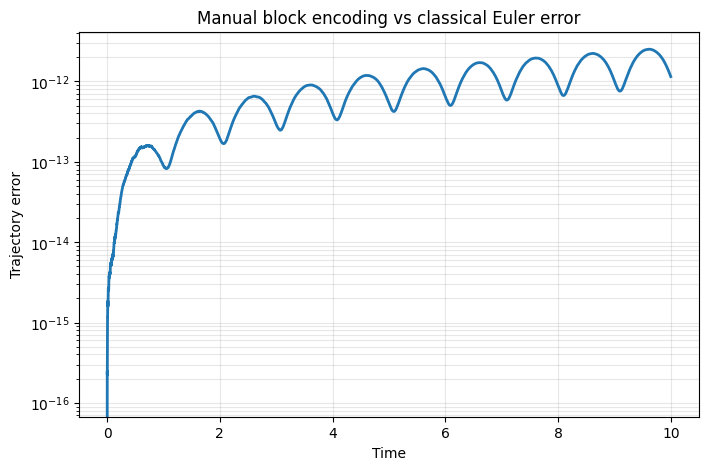

Maximum trajectory error: 2.51618637341664e-12


In [12]:
#Trajectory error: Comparison between two methods
trajectory_error = np.sqrt((x_be - x_cl)**2 + (y_be - y_cl)**2)

plt.figure(figsize=(8, 5))
plt.plot(t_cl, trajectory_error, linewidth=2)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Trajectory error")
plt.title("Manual block encoding vs classical Euler error")
plt.grid(True, which="both", alpha=0.3)
plt.show()

print("Maximum trajectory error:", np.max(trajectory_error))

# Manual block encoding (Using Statevector simulator)

The second implementation converts the same unitary matrix into a Qiskit `UnitaryGate` and simulates the circuit using `Statevector`. This is closer to a circuit-level simulation, although the arbitrary unitary synthesis is still not scalable for large matrices.

Constructing circuit for matrix by turning it to a quantum gate.

Qubit convention: 

q0: system

q1: ancilla

In [13]:
def create_manual_block_encoding_circuit(x, y, h, omega, alpha=None):
    system = 0
    ancilla = 1

    # The present time state/vector
    u = np.array([x, y], dtype=complex)
    norm_u = np.linalg.norm(u)

    if norm_u == 0:
        raise ValueError("Cannot prepare the zero vector as a quantum state.")

    #Angle to create the quantum circuit with desired x and y
    theta = 2 * np.arctan2(y, x)

    #preparing block encoding matrix
    M = pendulum_update_matrix(h, omega)
    U, alpha = manual_block_encoding(M, alpha=alpha)

    #Create quantum circuit with 2 qubits
    qc = QuantumCircuit(2)

    # Preparing real one-qubit system state with angle, theta
    qc.ry(theta, system)

    #Convert U into a quantum gate
    # Append U on [system, ancilla].
    # Qiskit basis for [q0, q1] is |q1 q0>, i.e. |ancilla system>.
    U_gate = UnitaryGate(U, label="U_BE")
    qc.append(U_gate, [system, ancilla])

    return qc, alpha, norm_u

One Euler step using Qiskit Statevector simulation of the manual block encoding.

In [14]:
def manual_block_step_statevector(x, y, h, omega, alpha=None):
    qc, alpha, norm_u = create_manual_block_encoding_circuit(
        x, y, h, omega, alpha=alpha
    )

    state = Statevector.from_instruction(qc).data

    # Ancilla success branch: ancilla = 0.
    success_branch = np.array([state[0], state[1]])

    # Recover unnormalized classical vector:
    # success_branch = M |psi> / alpha
    # u_next = alpha * ||u|| * success_branch
    u_next = alpha * norm_u * success_branch

    x_next = np.real_if_close(u_next[0]).real
    y_next = np.real_if_close(u_next[1]).real

    return x_next, y_next

In [16]:
def manual_block_trajectory_statevector(h, omega, x0, y0, n_steps, alpha=None):
    
    x_vals = [x0]
    y_vals = [y0]

    x, y = x0, y0

    for _ in range(n_steps):
        x, y = manual_block_step_statevector(
            x, y, h, omega, alpha=alpha
        )

        x_vals.append(x)
        y_vals.append(y)

    t_vals = np.arange(n_steps + 1) * h

    return t_vals, np.array(x_vals), np.array(y_vals)

### Trajectory Plots

In [17]:
h = 0.001
omega = np.sqrt(9.8)
x0 = np.pi/2
y0 = 1.0
n_steps = 10000

t_cl, x_cl, y_cl = classical_euler_linear_pendulum(
    h, omega, x0, y0, n_steps
)

t_be, x_be, y_be = manual_block_trajectory_statevector(
    h, omega, x0, y0, n_steps
)

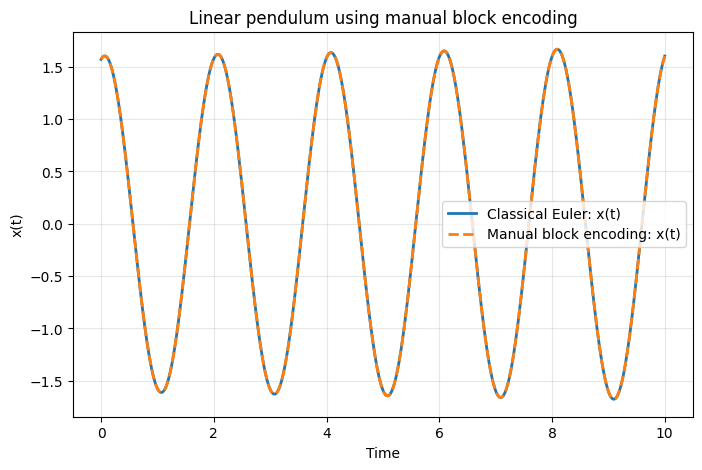

In [18]:
#Trajectory plots
plt.figure(figsize=(8, 5))
plt.plot(t_cl, x_cl, label="Classical Euler: x(t)", linewidth=2)
plt.plot(t_be, x_be, "--", label="Manual block encoding: x(t)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Linear pendulum using manual block encoding")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

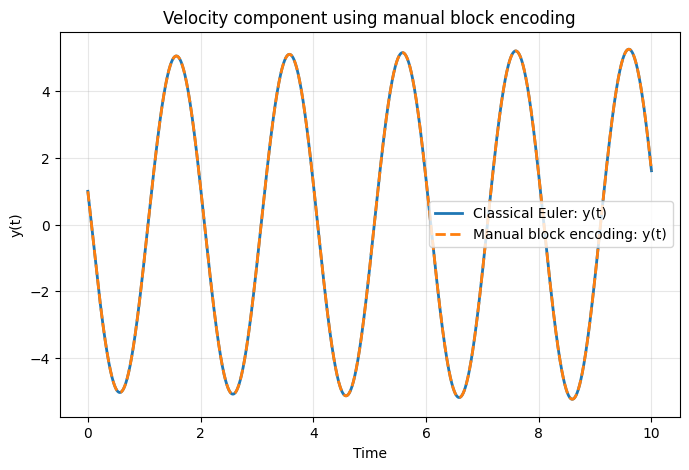

In [19]:
#Trajectory plot (Vecocity plot, y(t))
plt.figure(figsize=(8, 5))
plt.plot(t_cl, y_cl, label="Classical Euler: y(t)", linewidth=2)
plt.plot(t_be, y_be, "--", label="Manual block encoding: y(t)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("Velocity component using manual block encoding")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


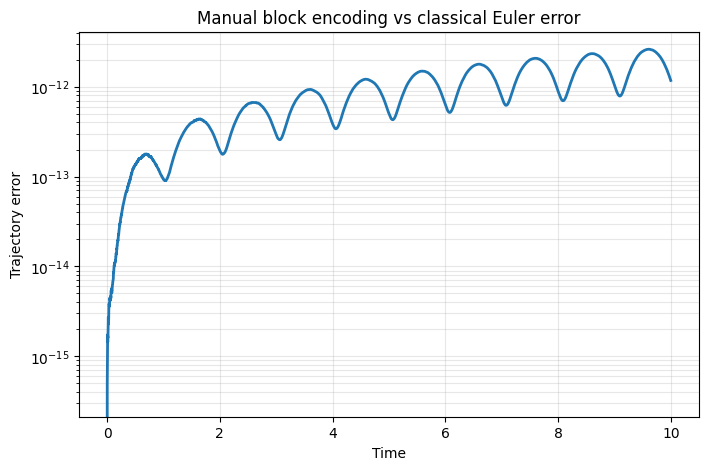

Maximum trajectory error: 2.6113578767326367e-12


In [20]:
#Error plot
trajectory_error = np.sqrt((x_be - x_cl)**2 + (y_be - y_cl)**2)

plt.figure(figsize=(8, 5))
plt.plot(t_cl, trajectory_error, linewidth=2)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Trajectory error")
plt.title("Manual block encoding vs classical Euler error")
plt.grid(True, which="both", alpha=0.3)
plt.show()

print("Maximum trajectory error:", np.max(trajectory_error))

# Manual Block encoding (measurements based)

One manual block-encoding step using measurements and QST.

Procedure:

1. Prepare $|0>_{anc} |\psi_n>_{sys}$.
        
2. Apply the manual block-encoding unitary gate.

3. Measure Z basis and post-select ancilla=0.

4. Measure X basis and post-select ancilla=0.

5. Reconstruct the normalized output state.

6. Use p_success to update the classical norm.

In [21]:
#Add measurements to a manual block-encoding circuit
def measured_block_encoding_circuit(qc, basis="Z"):
    qc_m = qc.copy()
    basis = basis.upper()

    system = 0
    ancilla = 1

    if basis == "X":
        qc_m.h(system)
    elif basis == "Y":
        qc_m.sdg(system)
        qc_m.h(system)
    elif basis != "Z":
        raise ValueError("basis must be 'X', 'Y', or 'Z'.")

    cr = ClassicalRegister(2, "c")
    qc_m.add_register(cr)

    qc_m.measure(system, cr[0])
    qc_m.measure(ancilla, cr[1])

    return qc_m

ost-select ancilla = 0 and compute the conditional expectation value of the measured system observable.

Count strings are c1 c0 = ancilla system.

 Successful strings:

        "00": ancilla=0, system=0
        "01": ancilla=0, system=1

In [22]:
def postselected_expectation_from_counts_2q(counts):
    n0 = counts.get("00", 0)
    n1 = counts.get("01", 0)

    n_success = n0 + n1
    total = sum(counts.values())

    if n_success == 0:
        return None, 0.0, n0, n1

    expectation = (n0 - n1) / n_success
    p_success = n_success / total

    return expectation, p_success, n0, n1

## State reconstruction

In [23]:
#Raw reconstruction of a real one-qubit state from <Z> and <X>
def reconstruct_real_state_from_xz_raw(exp_z, exp_x):
    exp_z = np.clip(exp_z, -1.0, 1.0)
    exp_x = np.clip(exp_x, -1.0, 1.0)

    a = np.sqrt((1 + exp_z) / 2)
    b_abs = np.sqrt((1 - exp_z) / 2)

    if abs(a) < 1e-12:
        b = b_abs
    else:
        b = np.sign(exp_x) * b_abs

    return np.array([a, b], dtype=float)


# Stable Construction
def reconstruct_real_state_from_xz_stable(exp_z, exp_x):
    r = np.sqrt(exp_x**2 + exp_z**2)

    if r > 1e-12:
        exp_x = exp_x / r
        exp_z = exp_z / r

    exp_z = np.clip(exp_z, -1.0, 1.0)

    a = np.sqrt((1 + exp_z) / 2)
    b_abs = np.sqrt((1 - exp_z) / 2)

    b = np.sign(exp_x) * b_abs

    return np.array([a, b], dtype=float)


def reconstruct_real_state_from_xz(exp_z, exp_x, method="stable"):
    if method == "raw":
        return reconstruct_real_state_from_xz_raw(exp_z, exp_x)
    elif method == "stable":
        return reconstruct_real_state_from_xz_stable(exp_z, exp_x)
    else:
        raise ValueError("method must be 'raw' or 'stable'.")

## One measurements step

In [24]:
def manual_block_step_qst(
    x,
    y,
    h,
    omega,
    shots=20000,
    simulator=None,
    alpha=None,
    reconstruction="stable",
    sign_fix="continuity"
):
    
    if simulator is None:
        simulator = AerSimulator()

    u_prev = np.array([x, y], dtype=float)
    norm_prev = np.linalg.norm(u_prev)

    if norm_prev == 0:
        return 0.0, 0.0, {
            "p_success_z": 0.0,
            "p_success_x": 0.0,
            "exp_z": None,
            "exp_x": None
        }

    qc, alpha, _ = create_manual_block_encoding_circuit(
        x, y, h, omega, alpha=alpha
    )

    # Z-basis measurement
    qc_z = measured_block_encoding_circuit(qc, basis="Z")
    tqc_z = transpile(qc_z, simulator)
    counts_z = simulator.run(tqc_z, shots=shots).result().get_counts()

    exp_z, p_success_z, n0_z, n1_z = postselected_expectation_from_counts_2q(
        counts_z
    )

    # X-basis measurement
    qc_x = measured_block_encoding_circuit(qc, basis="X")
    tqc_x = transpile(qc_x, simulator)
    counts_x = simulator.run(tqc_x, shots=shots).result().get_counts()

    exp_x, p_success_x, n0_x, n1_x = postselected_expectation_from_counts_2q(
        counts_x
    )

    if exp_z is None or exp_x is None:
        raise RuntimeError("No successful post-selected shots. Increase shots.")

    psi_next = reconstruct_real_state_from_xz(
        exp_z, exp_x, method=reconstruction
    )

    # Norm update from post-selection probability.
    norm_next = alpha * np.sqrt(p_success_z) * norm_prev

    u_next = norm_next * psi_next

    # QST cannot determine global sign. Use continuity as a convention.
    if sign_fix == "continuity":
        if np.dot(u_next, u_prev) < 0:
            u_next = -u_next

    diagnostics = {
        "alpha": alpha,
        "p_success_z": p_success_z,
        "p_success_x": p_success_x,
        "exp_z": exp_z,
        "exp_x": exp_x,
        "bloch_xz_norm": np.sqrt(exp_x**2 + exp_z**2),
        "n0_z": n0_z,
        "n1_z": n1_z,
        "n0_x": n0_x,
        "n1_x": n1_x,
        "n_success_z": n0_z + n1_z,
        "n_success_x": n0_x + n1_x
    }

    return u_next[0], u_next[1], diagnostics

## Full trajectory

In [25]:
# Full trajectory using manual block encoding with measurement/QST extraction
def manual_block_trajectory_qst(
    h,
    omega,
    x0,
    y0,
    n_steps,
    shots=20000,
    seed_simulator=1234,
    alpha=None,
    reconstruction="stable"
):
    simulator = AerSimulator(seed_simulator=seed_simulator)

    x_vals = [x0]
    y_vals = [y0]
    diagnostics = []

    x, y = x0, y0

    for _ in range(n_steps):
        x, y, diag = manual_block_step_qst(
            x,
            y,
            h,
            omega,
            shots=shots,
            simulator=simulator,
            alpha=alpha,
            reconstruction=reconstruction
        )

        x_vals.append(x)
        y_vals.append(y)
        diagnostics.append(diag)

    t_vals = np.arange(n_steps + 1) * h
    return t_vals, np.array(x_vals), np.array(y_vals), diagnostics

First case:

$\omega = 1$, $x_0 = 1$ and $y_0 = 0$  

In [41]:
h = 0.001
omega = 1
x0 = 1.0
y0 = 0.0
n_steps_qst = 20
shots = 100000

t_cl_qst, x_cl_qst, y_cl_qst = classical_euler_linear_pendulum(
    h, omega, x0, y0, n_steps_qst
)

t_qst, x_qst, y_qst, diag_qst = manual_block_trajectory_qst(
    h,
    omega,
    x0,
    y0,
    n_steps_qst,
    shots=shots,
    seed_simulator=1234,
    reconstruction="stable")

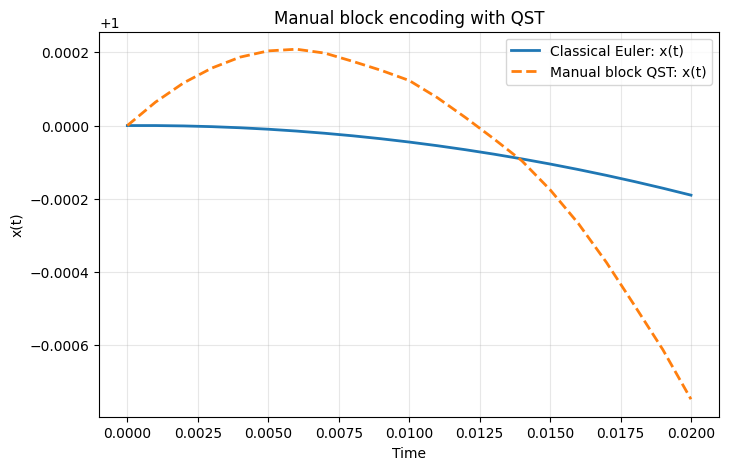

In [42]:
#x(t) plot
plt.figure(figsize=(8, 5))
plt.plot(t_cl_qst, x_cl_qst, label="Classical Euler: x(t)", linewidth=2)
plt.plot(t_qst, x_qst, "--", label="Manual block QST: x(t)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Manual block encoding with QST")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

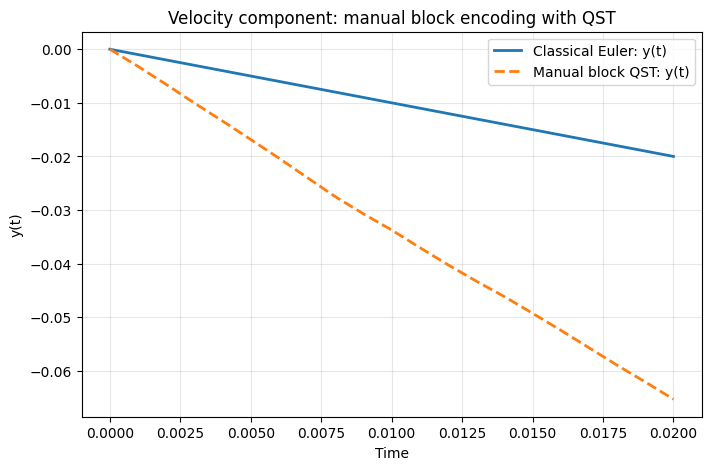

In [43]:
#y(t) plot
plt.figure(figsize=(8, 5))
plt.plot(t_cl_qst, y_cl_qst, label="Classical Euler: y(t)", linewidth=2)
plt.plot(t_qst, y_qst, "--", label="Manual block QST: y(t)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("Velocity component: manual block encoding with QST")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

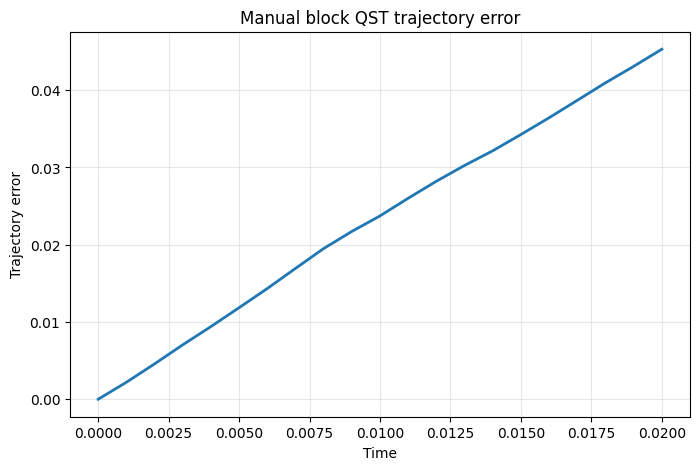

Final QST trajectory error: 0.04529573376908868
Max QST trajectory error: 0.04529573376908868


In [44]:
#Error plot
traj_error_qst = np.sqrt((x_qst - x_cl_qst)**2 + (y_qst - y_cl_qst)**2)

plt.figure(figsize=(8, 5))
plt.plot(t_cl_qst, traj_error_qst, linewidth=2)
plt.xlabel("Time")
plt.ylabel("Trajectory error")
plt.title("Manual block QST trajectory error")
plt.grid(True, alpha=0.3)
plt.show()

print("Final QST trajectory error:", traj_error_qst[-1])
print("Max QST trajectory error:", np.max(traj_error_qst))

Second case:

$\omega = \sqrt{9.8}$, $x_0 = \pi/2$ and $y_0 = 1.0$

In [45]:
h = 0.001
omega = np.sqrt(9.8)
x0 = np.pi/2
y0 = 1.0
n_steps_qst = 20
shots = 100000

t_cl_qst1, x_cl_qst1, y_cl_qst1 = classical_euler_linear_pendulum(
    h, omega, x0, y0, n_steps_qst
)

t_qst1, x_qst1, y_qst1, diag_qst = manual_block_trajectory_qst(
    h,
    omega,
    x0,
    y0,
    n_steps_qst,
    shots=shots,
    seed_simulator=1234,
    reconstruction="stable")

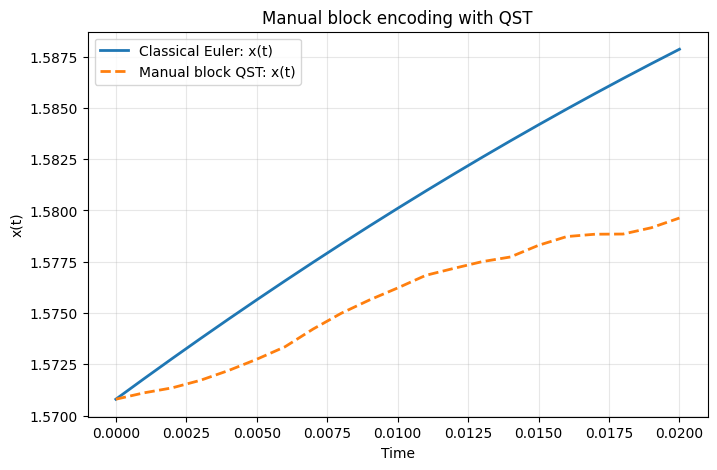

In [46]:
#x(t) plot
plt.figure(figsize=(8, 5))
plt.plot(t_cl_qst1, x_cl_qst1, label="Classical Euler: x(t)", linewidth=2)
plt.plot(t_qst1, x_qst1, "--", label="Manual block QST: x(t)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Manual block encoding with QST")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

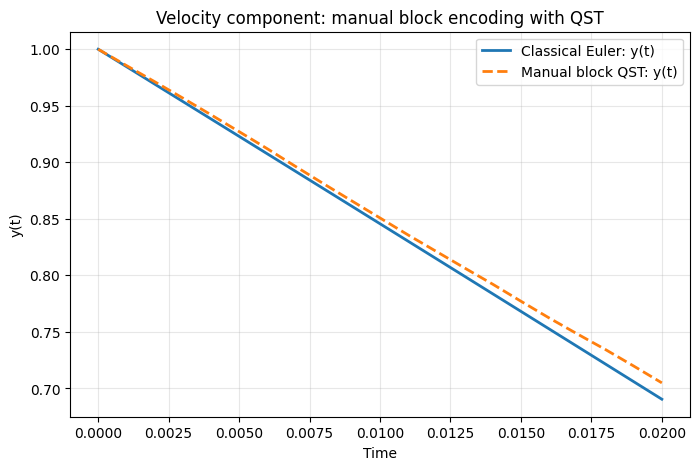

In [47]:
#y(t) plot
plt.figure(figsize=(8, 5))
plt.plot(t_cl_qst1, y_cl_qst1, label="Classical Euler: y(t)", linewidth=2)
plt.plot(t_qst1, y_qst1, "--", label="Manual block QST: y(t)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("Velocity component: manual block encoding with QST")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

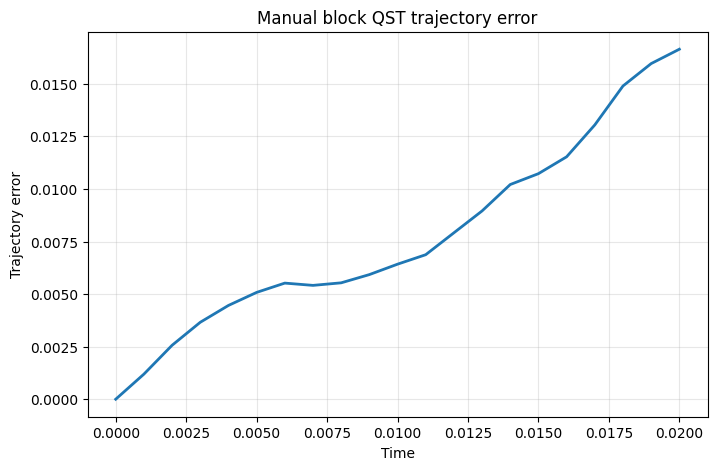

Final QST trajectory error: 0.01664345288073081
Max QST trajectory error: 0.01664345288073081


In [48]:
#Error plot
traj_error_qst1 = np.sqrt((x_qst1 - x_cl_qst1)**2 + (y_qst1 - y_cl_qst1)**2)

plt.figure(figsize=(8, 5))
plt.plot(t_cl_qst1, traj_error_qst1, linewidth=2)
plt.xlabel("Time")
plt.ylabel("Trajectory error")
plt.title("Manual block QST trajectory error")
plt.grid(True, alpha=0.3)
plt.show()

print("Final QST trajectory error:", traj_error_qst1[-1])
print("Max QST trajectory error:", np.max(traj_error_qst1))

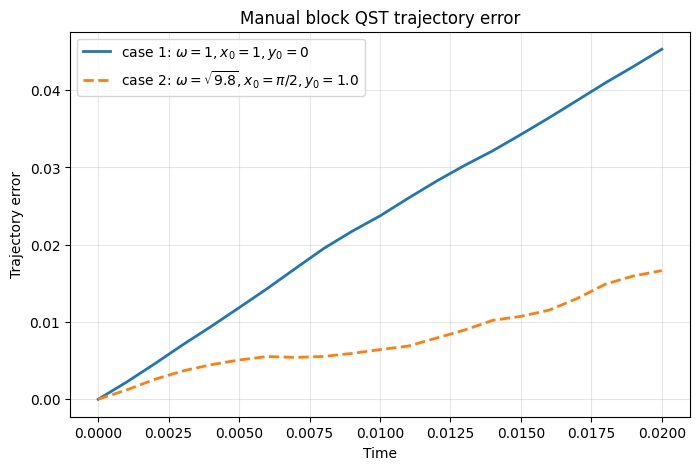

In [53]:
#Comparing both errors
plt.figure(figsize=(8, 5))
plt.plot(t_cl_qst, traj_error_qst, label = r"case 1: $\omega = 1, x_0=1, y_0 = 0 $",linewidth=2)
plt.plot(t_cl_qst1, traj_error_qst1,"--",label = r"case 2: $\omega = \sqrt{9.8}, x_0 = \pi/2, y_0 = 1.0$", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Trajectory error")
plt.title("Manual block QST trajectory error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Case I's initial condition is a harder case for QST because the first Euler step produces a very small $y$-component. The sign of this small component is inferred from $\langle X\rangle$, which is itself close to zero and therefore sensitive to finite-shot fluctuations.

## Post Selection probability 

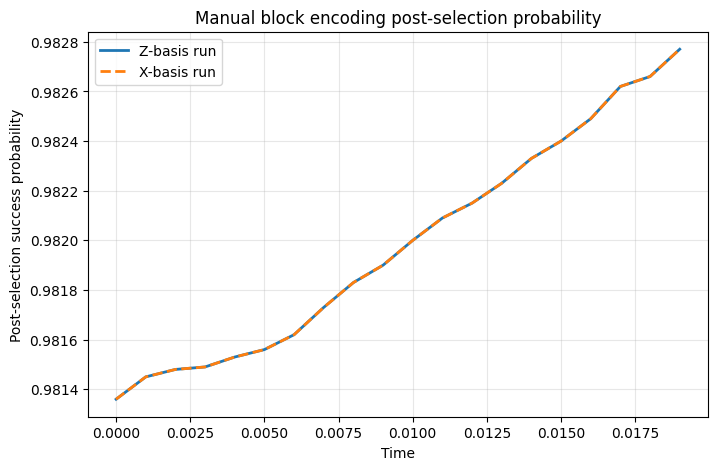

Mean p_success_z: 0.9819844999999999
Minimum p_success_z: 0.98136
Mean |p_z - p_x|: 0.0


In [54]:
p_success_z_vals = np.array([d["p_success_z"] for d in diag_qst])
p_success_x_vals = np.array([d["p_success_x"] for d in diag_qst])

plt.figure(figsize=(8, 5))
plt.plot(t_qst[:-1], p_success_z_vals, label="Z-basis run", linewidth=2)
plt.plot(t_qst[:-1], p_success_x_vals, "--", label="X-basis run", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Post-selection success probability")
plt.title("Manual block encoding post-selection probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Mean p_success_z:", np.mean(p_success_z_vals))
print("Minimum p_success_z:", np.min(p_success_z_vals))
print("Mean |p_z - p_x|:", np.mean(np.abs(p_success_z_vals - p_success_x_vals)))

## Norm Evolution

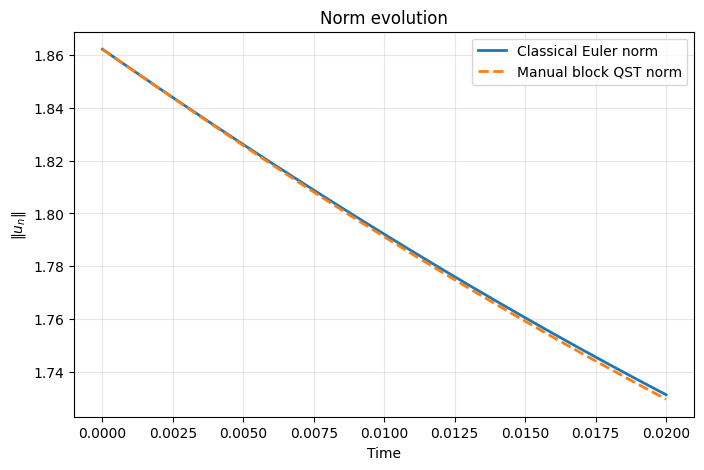

In [56]:
norm_cl = np.sqrt(x_cl_qst1**2 + y_cl_qst1**2)
norm_qst = np.sqrt(x_qst1**2 + y_qst1**2)

plt.figure(figsize=(8, 5))
plt.plot(t_cl_qst, norm_cl, label="Classical Euler norm", linewidth=2)
plt.plot(t_qst, norm_qst, "--", label="Manual block QST norm", linewidth=2)
plt.xlabel("Time")
plt.ylabel(r"$\|u_n\|$")
plt.title("Norm evolution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Error investigation

Found error is very high. So, investigating further

One-step error: Comparing statevector and QST

In [57]:
h = 0.001
omega = np.sqrt(9.8)
x0 = np.pi/2
y0 = 1.0
n_steps_qst = 20
shots = 100000

x_cl_1 = x0 + h * y0
y_cl_1 = y0 - h * omega**2 * x0

x_sv_1, y_sv_1 = manual_block_step_statevector(x0, y0, h, omega)

sim = AerSimulator(seed_simulator=1234)
x_qst_1, y_qst_1, diag_1 = manual_block_step_qst(
    x0, y0, h, omega, shots=20000, simulator=sim
)

print("Classical one step:", x_cl_1, y_cl_1)
print("Statevector one step:", x_sv_1, y_sv_1)
print("QST one step:", x_qst_1, y_qst_1)

print("One-step QST error:",
      np.sqrt((x_qst_1 - x_cl_1)**2 + (y_qst_1 - y_cl_1)**2))

print("exp_z:", diag_1["exp_z"])
print("exp_x:", diag_1["exp_x"])
print("bloch_xz_norm:", diag_1["bloch_xz_norm"])
print("p_success_z:", diag_1["p_success_z"])
print("p_success_x:", diag_1["p_success_x"])

Classical one step: 1.5717963267948964 0.9846061959974101
Statevector one step: 1.5717963267948964 0.9846061959974097
QST one step: 1.573264373835091 0.9817591254923471
One-step QST error: 0.0032032752883609057
exp_z: 0.4411659786984661
exp_x: 0.9017479488355501
bloch_xz_norm: 1.003880861452243
p_success_z: 0.98115
p_success_x: 0.98115


Comparing $<X>$ and $<Z>$ from measured and exact values:

In [58]:
def exact_xz_from_vector(x, y):
    norm = np.sqrt(x**2 + y**2)
    a = x / norm
    b = y / norm

    exp_z = a**2 - b**2
    exp_x = 2 * a * b

    return exp_z, exp_x

exp_z_exact, exp_x_exact = exact_xz_from_vector(x_cl_1, y_cl_1)

print(f"{'quantity':<12} {'exact':>15} {'measured':>15} {'difference':>15}")
print(f"{'<Z>':<12} {exp_z_exact:>15.8e} {diag_1['exp_z']:>15.8e} {diag_1['exp_z'] - exp_z_exact:>15.8e}")
print(f"{'<X>':<12} {exp_x_exact:>15.8e} {diag_1['exp_x']:>15.8e} {diag_1['exp_x'] - exp_x_exact:>15.8e}")

quantity               exact        measured      difference
<Z>           4.36365512e-01  4.41165979e-01  4.80046629e-03
<X>           8.99769492e-01  9.01747949e-01  1.97845636e-03


## Running for different shots:

In [59]:
for shots in [20_000, 50_000, 100_000, 200_000, 500_000, 1_000_000]:
    sim = AerSimulator(seed_simulator=1234)

    x_qst_1, y_qst_1, diag_1 = manual_block_step_qst(
        x0, y0, h, omega, shots=shots, simulator=sim
    )

    err = np.sqrt((x_qst_1 - x_cl_1)**2 + (y_qst_1 - y_cl_1)**2)

    print(
        shots,
        "error =", err,
        "p_success =", diag_1["p_success_z"],
        "bloch_norm =", diag_1["bloch_xz_norm"]
    )

20000 error = 0.0032032752883609057 p_success = 0.98115 bloch_norm = 1.003880861452243
50000 error = 0.0013004532228768609 p_success = 0.98034 bloch_norm = 0.9984748002253968
100000 error = 0.0011928906345680752 p_success = 0.98136 bloch_norm = 0.9975246700711552
200000 error = 0.0003968312699390396 p_success = 0.98155 bloch_norm = 0.9981951525110015
500000 error = 0.0006195668821324905 p_success = 0.981502 bloch_norm = 0.9998010369954035
1000000 error = 0.000706874068114969 p_success = 0.981489 bloch_norm = 1.0004245998726582


Even though error is small and decreasing. But, the behaviour is not monotonic. So, we run for different seeds as well.

Running for different seeds and different shots

In [60]:
shots_list = [20_000, 50_000, 100_000, 200_000, 500_000, 1_000_000]
seeds = range(1, 11)

avg_results = []

for shots in shots_list:
    errors = []
    p_successes = []
    bloch_norms = []

    for seed in seeds:
        sim = AerSimulator(seed_simulator=seed)

        x_qst_1, y_qst_1, diag_1 = manual_block_step_qst(
            x0, y0, h, omega, shots=shots, simulator=sim
        )

        err = np.sqrt((x_qst_1 - x_cl_1)**2 + (y_qst_1 - y_cl_1)**2)

        errors.append(err)
        p_successes.append(diag_1["p_success_z"])
        bloch_norms.append(diag_1["bloch_xz_norm"])

    avg_results.append({
        "shots": shots,
        "mean_error": np.mean(errors),
        "std_error": np.std(errors),
        "mean_p_success": np.mean(p_successes),
        "mean_bloch_norm": np.mean(bloch_norms),
        "std_bloch_norm": np.std(bloch_norms)
    })

for r in avg_results:
    print(
        r["shots"],
        "mean error =", r["mean_error"],
        "std error =", r["std_error"],
        "mean p_success =", r["mean_p_success"],
        "mean bloch norm =", r["mean_bloch_norm"]
    )

20000 mean error = 0.004359160800606153 std error = 0.0026897458309125787 mean p_success = 0.9813700000000001 mean bloch norm = 1.0011488771862833
50000 mean error = 0.0027442705900763004 std error = 0.0020072025235243645 mean p_success = 0.9815179999999998 mean bloch norm = 0.9997487227553975
100000 mean error = 0.002910389885431364 std error = 0.0015044936432324814 mean p_success = 0.9813890000000001 mean bloch norm = 1.0001386139603823
200000 mean error = 0.0018778472084787494 std error = 0.0010705647168411602 mean p_success = 0.9813594999999999 mean bloch norm = 1.0000183705888201
500000 mean error = 0.0008788850921566784 std error = 0.0007076914210036844 mean p_success = 0.9813991999999999 mean bloch norm = 1.0001639949750725
1000000 mean error = 0.0005521730540633337 std error = 0.00042779343697427457 mean p_success = 0.9814035000000001 mean bloch norm = 1.000059222495738


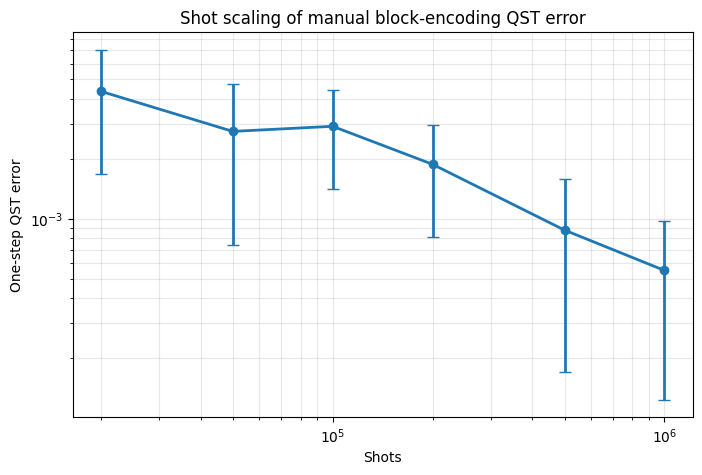

In [61]:
shots_arr = np.array([r["shots"] for r in avg_results])
mean_err = np.array([r["mean_error"] for r in avg_results])
std_err = np.array([r["std_error"] for r in avg_results])

plt.figure(figsize=(8, 5))
plt.errorbar(shots_arr, mean_err, yerr=std_err, fmt="o-", capsize=4, linewidth=2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Shots")
plt.ylabel("One-step QST error")
plt.title("Shot scaling of manual block-encoding QST error")
plt.grid(True, which="both", alpha=0.3)
plt.show()

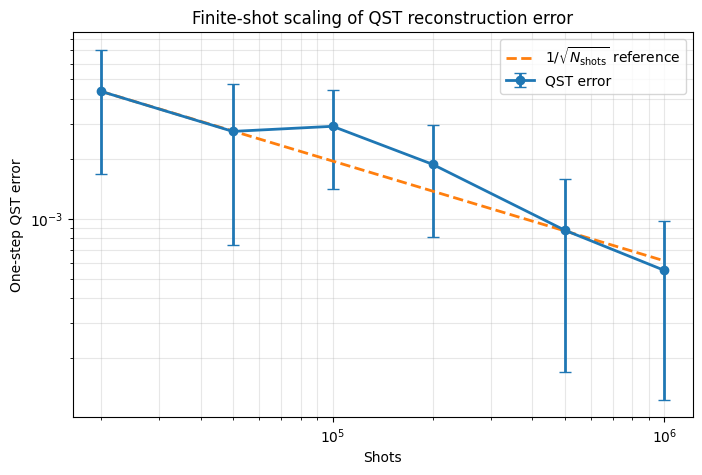

In [62]:
ref = mean_err[0] * np.sqrt(shots_arr[0] / shots_arr)

plt.figure(figsize=(8, 5))
plt.errorbar(shots_arr, mean_err, yerr=std_err, fmt="o-", capsize=4, label="QST error", linewidth=2)
plt.plot(shots_arr, ref, "--", label=r"$1/\sqrt{N_{\rm shots}}$ reference", linewidth=2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Shots")
plt.ylabel("One-step QST error")
plt.title("Finite-shot scaling of QST reconstruction error")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

Although the one-step QST error is small, it is recursively fed into the next time step in the hybrid loop. This produces visible trajectory drift over multiple steps. This behavior is not specific to the LCU construction; it also appears for manual block encoding, showing that full state reconstruction by QST is a readout bottleneck for time-stepping methods.

# Summary

Manual block encoding + exact statevector branch extraction reproduces Euler.

Manual block encoding + measurement/QST reproduces the update statistically, with the one-step reconstruction error decreasing approximately as $1/\sqrt{N_{\rm shots}}$.

## Next steps

This notebook used manual unitary dilation as the simplest block-encoding construction. The next notebook will replace this direct dilation with a matrix-entry oracle construction. In that approach, the entries $A_{ij}$ are encoded using controlled $R_y$ rotations, and Hadamard/SWAP operations convert entry loading into a block encoding of $A/N$. The optimized FABLE method then replaces the naive multi-controlled rotations with transformed angles and a Gray-code CNOT ladder.